Chunk 0: entry 0→628129, t ∈ [[1.69e+07, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [6e+11, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]


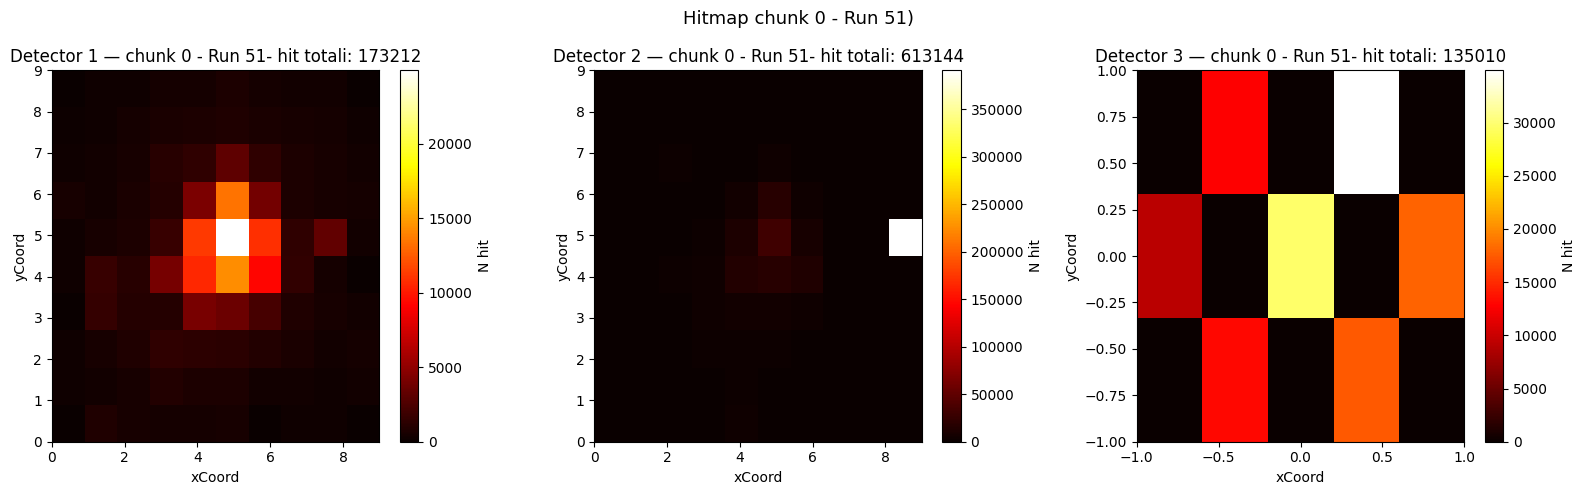

Chunk 1: entry 628129→638043, t ∈ [[6e+11, 6e+11, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [6.09e+11, 6.09e+11, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]


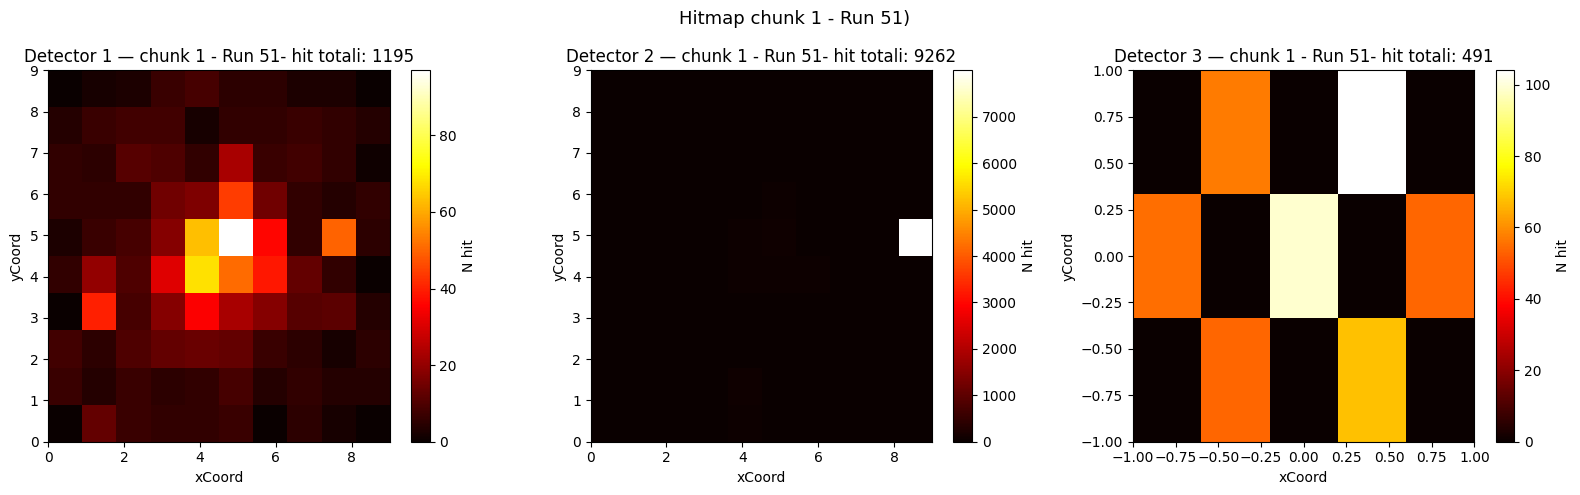

In [ ]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
run_number=51
# --- Parametri ---
TIME_STEP = 600_000_000_000  # intervallo fisso in unità di Cell0TimeStamp (es. 5 minuti in ns)

# --- 1. Pre-scan dei timestamp per trovare i bordi degli intervalli ---
with uproot.open(f"~/Scrivania/sampic_run{run_number}_merged.root") as f:
    tree = f["picoTree"]
    
    ts_jagged = tree["Cell0TimeStamp"].array(library="ak")
    timestamps = ak.to_numpy(ts_jagged[:, 0])  # prima entry di ogni evento
t_min = timestamps[0]
t_max = timestamps[-1]

# Bordi temporali fissi
time_edges = np.arange(t_min, t_max + TIME_STEP, TIME_STEP)

# Per ogni bordo temporale, trova l'indice di entry corrispondente
entry_edges = np.searchsorted(timestamps, time_edges)

# --- 2. Itera sui chunk definiti dagli indici calcolati ---
with uproot.open(f"~/Scrivania/sampic_run{run_number}_merged.root") as f:
    tree = f["picoTree"]

    for chunk_id, (start, stop) in enumerate(zip(entry_edges[:-1], entry_edges[1:])):
        if start >= stop:
            continue

        chunk = tree.arrays(
            ['Detector', 'Channel', 'Multiplicity', 'ArraySize',
             'xCoord', 'yCoord', 'Cell0TimeStamp'],
            library="ak",
            entry_start=start,
            entry_stop=stop
        )

        # Il tuo processing qui...
        print(f"Chunk {chunk_id}: entry {start}→{stop}, "
              f"t ∈ [{chunk['Cell0TimeStamp'][0]}, {chunk['Cell0TimeStamp'][-1]}]")
        det        = ak.to_numpy(chunk['Detector'])
        mult       = ak.to_numpy(chunk['Multiplicity'])
        array_size = ak.to_numpy(chunk['ArraySize'])
        xcoord     = ak.to_numpy(chunk['xCoord'])
        ycoord     = ak.to_numpy(chunk['yCoord'])
        Cell0TimeStamp = ak.to_numpy(chunk['Cell0TimeStamp'])

        # --- Hitmap per detector ---
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        for i, det_id in enumerate([1, 2, 3]):

            x_hits = []
            y_hits = []

            for evt in range(len(array_size)):
                n_hit = array_size[evt]

                for hit in range(n_hit):

                    if det[evt, hit] == det_id:
                        x_hits.append(xcoord[evt, hit])
                        y_hits.append(ycoord[evt, hit])

            if len(x_hits) == 0:
                axes[i].set_title(f"Detector {det_id} — nessuna hit")
                axes[i].axis('off')
                continue

            x_hits = np.array(x_hits)
            y_hits = np.array(y_hits)

            # Valori unici coordinate
            x_unique = np.sort(np.unique(x_hits))
            y_unique = np.sort(np.unique(y_hits))

            # Costruisci hitmap
            hitmap = np.zeros((len(y_unique), len(x_unique)))

            for x, y in zip(x_hits, y_hits):
                ix = np.where(x_unique == x)[0][0]
                iy = np.where(y_unique == y)[0][0]
                hitmap[iy, ix] += 1

            im = axes[i].imshow(
                hitmap,
                origin='lower',
                aspect='auto',
                extent=[
                    x_unique[0], x_unique[-1],
                    y_unique[0], y_unique[-1]
                ],
                cmap='hot'
            )

            plt.colorbar(im, ax=axes[i], label='N hit')

            axes[i].set_xlabel("xCoord")
            axes[i].set_ylabel("yCoord")
            axes[i].set_title(
                f"Detector {det_id} — chunk {chunk_id} - Run {run_number}- hit totali: {len(x_hits)}"
            )

        plt.suptitle(f"Hitmap chunk {chunk_id} - Run {run_number})", fontsize=13)
        plt.tight_layout()
        plt.show()